## logsumexp

### 1. Formulation

$\text{LogSumExp}(x) = \log\left(\sum_{i=1}^{n} e^{x_i}\right)$

torch 的文档：https://docs.pytorch.org/docs/stable/generated/torch.logsumexp.html



### 2. Why exist as a function

之所以单独是一个函数，因为核心是做了 - max 的优化，和上面手写的 softmax 一样的道理

为什么会存在这个函数？（核心：数值稳定性）

直接按上面的公式 $\log(\sum e^{x_i})$ 计算，在计算机中会遇到巨大的**数值稳定性**问题。

**问题在于 $e^{x_i}$ 这一步。**

指数函数增长极快。在标准的 64 位浮点数中， $e^{710}$ 就会被认为是无穷大 (inf)，即“上溢” (Overflow)；而 $e^{-745}$ 就会被认为是 0，即“下溢” (Underflow)。

举个例子：假设 $x = [1000, 1000]$

- **天真的计算 (Naive Calculation):**
    1. $e^{1000} \rightarrow \text{inf}$
    2. $e^{1000} \rightarrow \text{inf}$
    3. $\sum e^{x_i} = \text{inf} + \text{inf} \rightarrow \text{inf}$
    4. $\log(\text{inf}) \rightarrow \text{inf}$
- **你得到的结果是 `inf`，这是错误的。**
- 正确的计算 (True Value):
    
    $\log(e^{1000} + e^{1000}) = \log(2 \cdot e^{1000}) = \log(2) + \log(e^{1000}) = \log(2) + 1000 \approx 0.693 + 1000 = 1000.693$
    
- **天真计算的结果 `inf` 和正确结果 `1000.693` 相差甚远。**

为了解决这个问题，`torch.logsumexp` 这样的库函数在内部使用了一个数学技巧。

这个技巧是：**先减去向量中的最大值，计算完毕后，再加回来。**

设 $x_{\max} = \max(x_1, ..., x_n)$

$\text{LogSumExp}(x) = \log\left(\sum_{i=1}^{n} e^{x_i}\right)$

$= \log\left(\sum_{i=1}^{n} e^{x_i - x_{\max} + x_{\max}}\right)$

$= \log\left(\sum_{i=1}^{n} e^{x_i - x_{\max}} \cdot e^{x_{\max}}\right)$

$= \log\left(e^{x_{\max}} \cdot \sum_{i=1}^{n} e^{x_i - x_{\max}}\right)$

$= \log(e^{x_{\max}}) + \log\left(\sum_{i=1}^{n} e^{x_i - x_{\max}}\right)$

$= x_{\max} + \log\left(\sum_{i=1}^{n} e^{x_i - x_{\max}}\right)$

**为什么这个技巧能行？**

- $x_i - x_{\max}$ 这一项，最大值是 $0$ (当 $x_i$ 本身就是 $x_{\max}$ 时)，其他值都是负数。
- $e^0 = 1$
- $e^{\text{负数}}$ 是一个 0 到 1 之间的小数。
- **关键点：** $\sum e^{x_i - x_{\max}}$ 这个和，既不会大到“上溢”（因为最大项是 1），也不会小到“下溢”（因为它至少包含一个 1），因此在数值上是极其稳定的。

**所以，LogSumExp 函数存在的核心理由就是：它是一种能以数值稳定的方式，计算** $\log(\sum e^{x_i})$ **的方法。**


### 3. Mathematical properties

LogSumExp 函数在数学上有一个非常有趣的特性：**它是一个“平滑”的 (Smooth) 或“柔软”的 (Soft) maximum (最大值) 函数。**

$\text{LogSumExp}(x) \approx \max(x)$


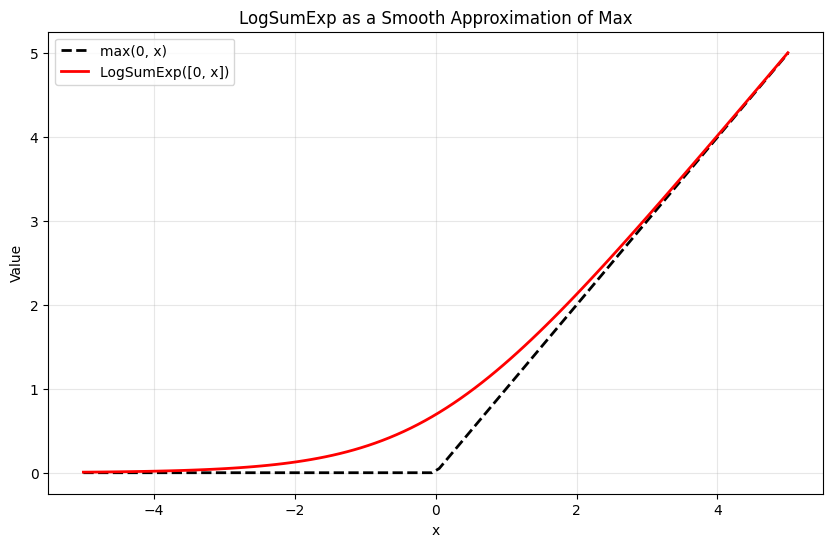

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Define the range for x
x_vals = np.linspace(-5, 5, 100)

# Calculate max(0, x) and LogSumExp([0, x])
# We compare max(0, x) vs log(e^0 + e^x) = log(1 + e^x) aka Softplus
max_vals = [max(0, x) for x in x_vals]
lse_vals = [torch.logsumexp(torch.tensor([0.0, x]), dim=0).item() for x in x_vals]

plt.figure(figsize=(10, 6))
plt.plot(x_vals, max_vals, label='max(0, x)', linestyle='--', color='black', linewidth=2)
plt.plot(x_vals, lse_vals, label='LogSumExp([0, x])', color='red', linewidth=2)

plt.title('LogSumExp as a Smooth Approximation of Max')
plt.xlabel('x')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**直观理解：**

假设 $x = [1, 5, 10]$

$\sum e^{x_i} = e^1 + e^5 + e^{10}$

$e^{10}$ ($\approx 22026$) 远远大于 $e^5$ ($\approx 148$) 和 $e^1$ ($\approx 2.7$)。

这个和 $\sum e^{x_i}$ 基本上被 $e^{10}$ 这一项主宰了。

$\log(\sum e^{x_i}) \approx \log(e^{10}) = 10$

所以 $\text{LogSumExp}(x)$ 的值非常接近 $\max(x)$

这个特性非常重要，因为 `max()` 函数是“尖锐”的、不可导的（在拐点处），而 LogSumExp 处处光滑可导。在机器学习中，**可导性 (Differentiability)** 是使用梯度下降进行优化的前提。

### 4. Code Implementation

手动实现这个函数


In [3]:
def logsumexp_torch(x: torch.Tensor, dim: int) -> torch.Tensor:
    # 1. 找到 x_max
    # 我们必须使用 keepdim=True，以便 x_max 可以从 x 中正确广播减去。
    # .values (或 [0]) 是因为 torch.max 返回 (values, indices)
    x_max = torch.max(x, dim=dim, keepdim=True)[0]

    # 2. 计算 x - x_max
    # 这一步是核心：(x_i - x_max) 永远 <= 0
    # 这确保了 exp() 的输入永远不会是大的正数，从而避免了上溢。
    x_stable = x - x_max

    # 3. 计算 exp(x - x_max)
    x_exp = torch.exp(x_stable)

    # 4. 计算 log(sum(exp(...)))
    # 此时 x_exp 是一个 [0, 1] 范围内的稳定值
    # 我们在这里使用 keepdim=True 来简化第 5 步的加法
    x_logsum = torch.log(torch.sum(x_exp, dim=dim, keepdim=True))

    # 5. 加上 x_max
    # result = x_max + log(...)
    # (N, 1) + (N, 1) -> (N, 1)
    result = x_max + x_logsum

    return result


### 5. Application

**最核心、最常见的应用：计算 LogSoftmax 和交叉熵损失 (Cross-Entropy Loss)。**

**应用一：LogSoftmax 的归一化项**

在分类问题中，我们使用 Softmax 函数将模型的原始输出（称为 logits）转换为概率分布。

$\text{Softmax}(x)_j = \frac{e^{x_j}}{\sum_{i=1}^{n} e^{x_i}}$

在训练中，我们通常计算损失的对数，即 LogSoftmax：

$\text{LogSoftmax}(x)_j = \log\left(\frac{e^{x_j}}{\sum_{i=1}^{n} e^{x_i}}\right)$

使用对数运算法则 $\log(a/b) = \log(a) - \log(b)$，我们得到：

$\text{LogSoftmax}(x)_j = \log(e^{x_j}) - \log\left(\sum_{i=1}^{n} e^{x_i}\right)$

$\text{LogSoftmax}(x)_j = x_j - \text{LogSumExp}(x)$

看到了吗？**LogSumExp 就是 LogSoftmax 函数的对数归一化项 (log-normalizer)。**

**应用二：交叉熵损失 (Cross-Entropy Loss)**

在 PyTorch 中，`torch.nn.CrossEntropyLoss` 实际上是 **`LogSoftmax`** 和 **`NLLLoss`** (负对数似然损失) 的组合。

当你计算损失时，比如正确的类别是 $j$，损失函数就是：

$\text{Loss} = -\text{LogSoftmax}(x)_j$

$\text{Loss} = -(x_j - \text{LogSumExp}(x))$

$\text{Loss} = \text{LogSumExp}(x) - x_j$

PyTorch 和 TensorFlow 等框架在计算交叉熵损失时，会**在底层调用 LogSumExp 技巧**来保证计算的数值稳定性。如果你试图自己手动实现 `log(softmax(x))`，几乎肯定会遇到 `inf` 或 `nan` (Not a Number) 的问题。

**应用三：概率模型**

 在许多概率图模型或能量基础模型 (EBMs) 中，需要计算一个“配分函数” (Partition Function) $Z = \sum e^{-E(x)}$，它对所有可能的状态求和。计算 $\log(Z)$ 时，就需要用到 $\text{LogSumExp}$。

**应用四：强化学习**

 在一些需要 "soft" 策略的算法中（如 Soft Q-Learning），LSE 被用作 `max` 算子的可微替代品，以平衡探索 (exploration) 和利用 (exploitation)。